# Libraries

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.multioutput import MultiOutputRegressor, MultiOutputClassifier
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score
import shap



/Users/asadbek/Library/Python/3.9/lib/python/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
df=pd.read_csv("all_brands.csv")


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   brand        1500 non-null   object
 1   model        1500 non-null   object
 2   trim         258 non-null    object
 3   price        1500 non-null   int64 
 4   year         1500 non-null   int64 
 5   description  1500 non-null   object
 6   place        1500 non-null   object
dtypes: int64(2), object(5)
memory usage: 82.2+ KB


# Multi Outpout Regressor

In [4]:
# target cols, x, y

target_cols = ['price', 'year']
X = df.drop(columns=target_cols)
y = df[target_cols]

In [5]:
# train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [6]:
# categorical features
categorical_features = ['brand', 'model', "trim", "description", "place"]

In [7]:
# categorical transformer
categorical_transformer = Pipeline(steps=[
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

In [8]:
# pipeline for preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', categorical_transformer, categorical_features)
    ]
)

In [9]:
# model
base_model = RandomForestRegressor(random_state=42, n_estimators=100, max_depth=10)

In [10]:
base_model

RandomForestRegressor(max_depth=10, random_state=42)

In [11]:
# multioutput regressor
multioutput_model = MultiOutputRegressor(base_model)

In [12]:
multioutput_model

MultiOutputRegressor(estimator=RandomForestRegressor(max_depth=10,
                                                     random_state=42))

In [13]:
# pipeline for preprocessing and model
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', multioutput_model)
])


In [14]:
pipeline

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('cat',
                                                  Pipeline(steps=[('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['brand', 'model', 'trim',
                                                   'description', 'place'])])),
                ('regressor',
                 MultiOutputRegressor(estimator=RandomForestRegressor(max_depth=10,
                                                                      random_state=42)))])

In [15]:
# Fit the pipeline on the training data
pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('cat',
                                                  Pipeline(steps=[('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['brand', 'model', 'trim',
                                                   'description', 'place'])])),
                ('regressor',
                 MultiOutputRegressor(estimator=RandomForestRegressor(max_depth=10,
                                                                      random_state=42)))])

In [16]:
# predict on the test data
y_pred = pipeline.predict(X_test)

In [17]:
y_pred

array([[24077.00780476,  2025.28215185],
       [16441.57261912,  2019.73056446],
       [ 2569.5161761 ,  2002.82410346],
       [ 4667.70077363,  2012.64177121],
       [ 2569.5161761 ,  2003.31073234],
       [22353.34693187,  2023.72126431],
       [24077.00780476,  2025.27079383],
       [37041.65091541,  2023.69575798],
       [16247.29908098,  2016.60959728],
       [10417.53449463,  2020.33698502],
       [23542.19282143,  2023.44295302],
       [15856.07977179,  2009.39697643],
       [22353.34693187,  2023.69575798],
       [16494.9210634 ,  2019.64381995],
       [10385.50982797,  2020.32288398],
       [16381.0861259 ,  2013.18684002],
       [16381.0861259 ,  2019.28477081],
       [33877.75040719,  2023.69575798],
       [ 2520.93586132,  2008.81259069],
       [ 4304.60083332,  2014.08581392],
       [24077.00780476,  2025.16103322],
       [24077.00780476,  2023.28732114],
       [24077.00780476,  2025.02887178],
       [16247.29908098,  2017.47881058],
       [71558.68

In [18]:
target_cols

['price', 'year']

In [19]:
for i, target in enumerate(target_cols):
    mse = mean_squared_error(y_test[target], y_pred[:, i])
    r2 = r2_score(y_test[target], y_pred[:, i])
    print(f"Metrics for {target}:")
    print(f"Mean Squared Error: {mse}")
    print(f"R^2 Score: {r2}")

Metrics for price:
Mean Squared Error: 42728779.863475636
R^2 Score: 0.72820553359985
Metrics for year:
Mean Squared Error: 19.48046073335917
R^2 Score: 0.7578027785986372


# Multi Output Classifier

In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   brand        1500 non-null   object
 1   model        1500 non-null   object
 2   trim         258 non-null    object
 3   price        1500 non-null   int64 
 4   year         1500 non-null   int64 
 5   description  1500 non-null   object
 6   place        1500 non-null   object
dtypes: int64(2), object(5)
memory usage: 82.2+ KB


In [21]:
# target cols, x, y for multi-output classification

target_cols = ['brand', 'model']
X = df.drop(columns=target_cols)
y = df[target_cols]

In [22]:
# train-test split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [23]:
# numeric and categorical features
numeric_features = ['price', 'year']
categorical_features = [col for col in X.columns if col not in numeric_features]

In [24]:
# numeric transformer
numeric_transformer = Pipeline(steps=[
    ('scaler', MinMaxScaler())
])


In [25]:
# categorical transformer
categorical_transformer = Pipeline(steps=[
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

In [26]:
# pipeline for preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

In [27]:
base_model=RandomForestClassifier(random_state=42, n_estimators=100, max_depth=10)

In [28]:
base_model

RandomForestClassifier(max_depth=10, random_state=42)

In [29]:
multi_output_classifier = MultiOutputClassifier(base_model)

In [30]:
multi_output_classifier

MultiOutputClassifier(estimator=RandomForestClassifier(max_depth=10,
                                                       random_state=42))

In [31]:
# pipeline for preprocessing and model
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', multi_output_classifier)
])


In [32]:
pipeline

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('scaler',
                                                                   MinMaxScaler())]),
                                                  ['price', 'year']),
                                                 ('cat',
                                                  Pipeline(steps=[('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['trim', 'description',
                                                   'place'])])),
                ('classifier',
                 MultiOutputClassifier(estimator=RandomForestClassifier(max_depth=10,
                                                                        random_state=42)))])

In [33]:
pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('scaler',
                                                                   MinMaxScaler())]),
                                                  ['price', 'year']),
                                                 ('cat',
                                                  Pipeline(steps=[('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['trim', 'description',
                                                   'place'])])),
                ('classifier',
                 MultiOutputClassifier(estimator=RandomForestClassifier(max_depth=10,
                                                                        random_state=42)))])

In [34]:
y_pred = pipeline.predict(X_test)

In [35]:
y_pred

array([['Kia', 'K5'],
       ['Hyundai', 'K5'],
       ['Daewoo', 'Nexia'],
       ['Hyundai', 'Nexia'],
       ['Daewoo', 'Nexia'],
       ['Kia', 'K5'],
       ['BYD', 'K5'],
       ['BYD', 'K5'],
       ['Kia', 'K5'],
       ['Chevrolet', 'Gentra'],
       ['BYD', 'K5'],
       ['Daewoo', 'K5'],
       ['Kia', 'K5'],
       ['Kia', 'K5'],
       ['Chevrolet', 'Gentra'],
       ['Hyundai', 'K5'],
       ['Hyundai', 'K5'],
       ['Kia', 'K5'],
       ['Daewoo', 'Nexia'],
       ['Chevrolet', 'Nexia 2'],
       ['Kia', 'K5'],
       ['Kia', 'K5'],
       ['BYD', 'K5'],
       ['Daewoo', 'Nexia'],
       ['BYD', 'K5'],
       ['Daewoo', 'Nexia'],
       ['Daewoo', 'Nexia'],
       ['Hyundai', 'K5'],
       ['BYD', 'K5'],
       ['Daewoo', 'Nexia'],
       ['BYD', 'K5'],
       ['Kia', 'K5'],
       ['Hyundai', 'K5'],
       ['BYD', 'K5'],
       ['Chevrolet', 'Cobalt'],
       ['Daewoo', 'Nexia'],
       ['Chevrolet', 'Matiz (Standart)'],
       ['Daewoo', 'Nexia'],
       ['Kia', 'K5'

In [36]:
for i, target in enumerate(target_cols):
    accuracy_score_value = accuracy_score(y_test[target], y_pred[:, i])
    print(f"Accuracy for {target}: {accuracy_score_value}")
    # confusion_matrix = pd.crosstab(y_test[target], y_pred[:, i], rownames=['Actual'], colnames=['Predicted'])
    # print(f"Confusion Matrix for {target}:")
    # print(confusion_matrix)


Accuracy for brand: 0.6333333333333333
Accuracy for model: 0.21333333333333335


# Shap


In [45]:
# target cols, x, y

target_col = ['price']
X = df.drop(columns=target_col)
y = df[target_col]

# train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# categorical features
numeric_features=["year"]
categorical_features = [col for col in X.columns if col not in numeric_features]

# numeric transformer
numeric_transformer = Pipeline(steps=[
    ('scaler', MinMaxScaler())
])

# categorical transformer
categorical_transformer = Pipeline(steps=[
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

# pipeline for preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

base_model=RandomForestRegressor(random_state=42, n_estimators=100, max_depth=10)




In [46]:
# pipeline for preprocessing and model
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', base_model)
])


In [47]:
pipeline.fit(X_train, y_train)

/Users/asadbek/Library/Python/3.9/lib/python/site-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('scaler',
                                                                   MinMaxScaler())]),
                                                  ['year']),
                                                 ('cat',
                                                  Pipeline(steps=[('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['brand', 'model', 'trim',
                                                   'description', 'place'])])),
                ('regressor',
                 RandomForestRegressor(max_depth=10, random_state=42))])

In [48]:
y_pred = pipeline.predict(X_test)

In [49]:
y_pred

array([25530.23933115, 21531.31168657,  2043.96345253, 12363.62843638,
        2841.98763774, 25118.12150191, 25530.23933115, 44738.60761348,
       24940.6888843 , 12524.57901569, 25684.18429104, 11481.0612779 ,
       24940.6888843 , 20949.7446261 ,  8703.92896586, 15373.76248148,
       22079.15109195, 42580.59181016,  1859.12517874,  4712.11811256,
       25530.23933115, 24940.6888843 , 24940.6888843 ,  6908.14548044,
       71090.31513214,  2935.01037765,  6595.93395501, 21768.19612301,
       72060.77441645,  6908.14548044, 25530.23933115, 25684.18429104,
       15236.99008137, 25530.23933115,  8991.89882224,  2047.11602041,
        2188.29161022,  1867.49815975, 22857.59982795,  8416.06054417,
        6962.37414071,  4491.54910734,  3846.384608  , 24940.6888843 ,
       25530.23933115,  3177.98440459,  1145.65772056,  3183.56944878,
       13327.6912294 , 23338.07202747, 17317.58064892,  3191.35956278,
       24940.6888843 , 24046.35800959,  2956.38513193, 25684.18429104,
      

In [50]:
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"Mean Squared Error: {mse}")
print(f"R^2 Score: {r2}")

Mean Squared Error: 30407714.143384654
R^2 Score: 0.8065788804066902


In [54]:
import shap

# Preprocess the test data
X_test_preprocessed = pipeline.named_steps["preprocessor"].transform(X_test)

# Convert sparse matrix to dense
X_test_dense = X_test_preprocessed.toarray()

# Get transformed feature names (after OneHotEncoder)
feature_names = pipeline.named_steps["preprocessor"].get_feature_names_out()

# Get trained model
model = pipeline.named_steps["regressor"]

# Create explainer
explainer = shap.TreeExplainer(model)

# New SHAP API
explanation = explainer(X_test_dense)

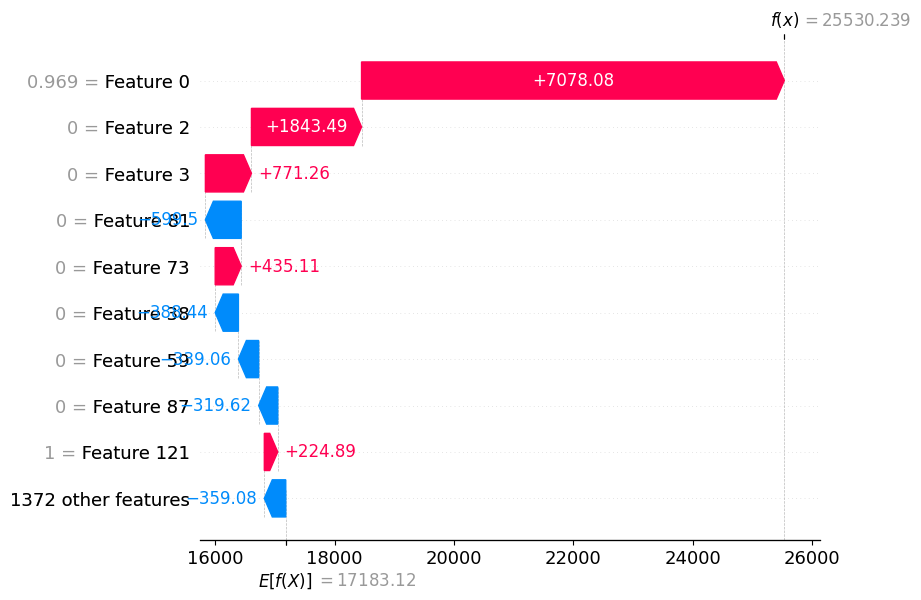

In [55]:
shap.plots.waterfall(explanation[0])

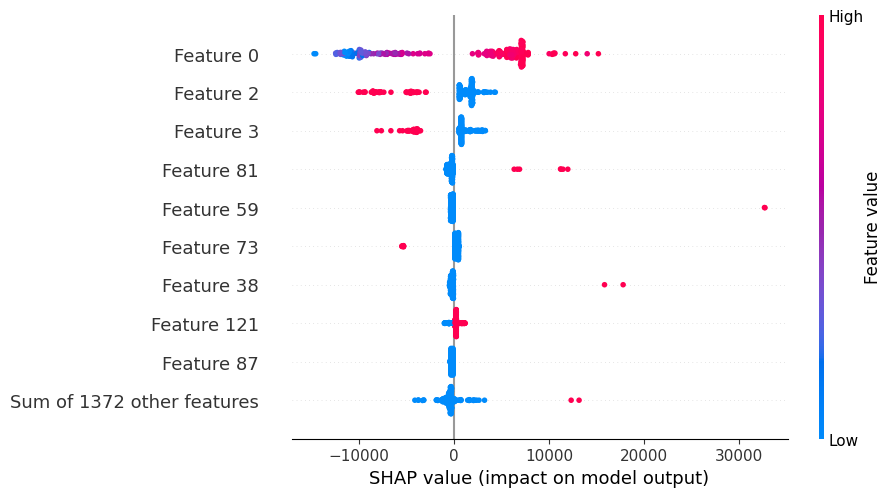

In [56]:
shap.plots.beeswarm(explanation)

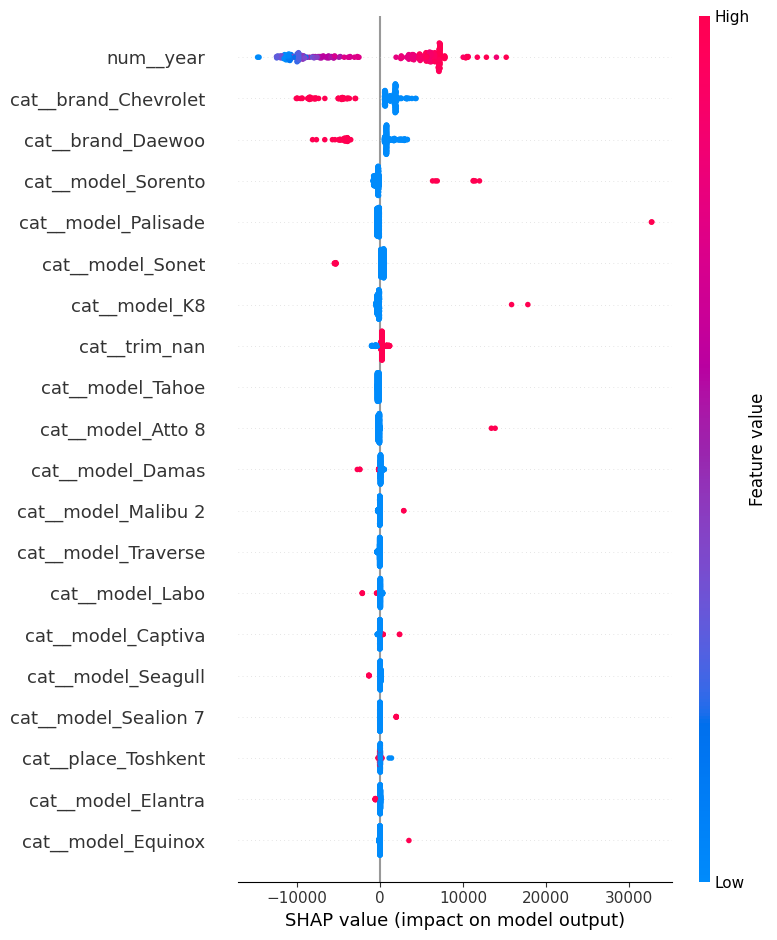

In [57]:
shap.summary_plot(
    explanation.values,
    X_test_dense,
    feature_names=feature_names
)